In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.dummy import DummyRegressor
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, root_mean_squared_error
from sklearn.pipeline import Pipeline
from sklearn.model_selection import cross_val_score

print("Environnement prêt")

Environnement prêt


In [6]:
df = pd.read_csv("../data/raw/bluebook-for-bulldozers/TrainAndValid.csv",
                 low_memory=False)

In [7]:
df.shape

(412698, 53)

In [8]:
df.head()

,SalesID,SalePrice,MachineID,ModelID,datasource,auctioneerID,YearMade,MachineHoursCurrentMeter,UsageBand,saledate,...,Undercarriage_Pad_Width,Stick_Length,Thumb,Pattern_Changer,Grouser_Type,Backhoe_Mounting,Blade_Type,Travel_Controls,Differential_Type,Steering_Controls
0,1139246,66000.0,999089,3157,121,3.0,2004,68.0,Low,11/16/2006 0:00,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Standard,Conventional
1,1139248,57000.0,117657,77,121,3.0,1996,4640.0,Low,3/26/2004 0:00,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Standard,Conventional
2,1139249,10000.0,434808,7009,121,3.0,2001,2838.0,High,2/26/2004 0:00,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,1139251,38500.0,1026470,332,121,3.0,2001,3486.0,High,5/19/2011 0:00,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,1139253,11000.0,1057373,17311,121,3.0,2007,722.0,Medium,7/23/2009 0:00,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [9]:
df.dtypes

SalesID                       int64
SalePrice                   float64
MachineID                     int64
ModelID                       int64
datasource                    int64
auctioneerID                float64
YearMade                      int64
MachineHoursCurrentMeter    float64
UsageBand                       str
saledate                        str
fiModelDesc                     str
fiBaseModel                     str
fiSecondaryDesc                 str
fiModelSeries                   str
fiModelDescriptor               str
ProductSize                     str
fiProductClassDesc              str
state                           str
ProductGroup                    str
ProductGroupDesc                str
Drive_System                    str
Enclosure                       str
Forks                           str
Pad_Type                        str
Ride_Control                    str
Stick                           str
Transmission                    str
Turbocharged                

In [10]:
df["SalesID"].nunique()
df.shape[0]

412698

Unité d'observation

Une ligne correspond à une transaction de vente aux enchères d'un engin.
'SalesID' est unique (412 698 valeurs distinctes = 412 698 lignes).

In [11]:
df["MachineID"].nunique()


348808

In [12]:
df["MachineID"].value_counts().head(100)


MachineID
2283592    48
2285830    44
1896854    40
1746392    34
2268800    31
           ..
2303682    13
2271989    13
2269961    13
2296171    13
2267787    13
Name: count, Length: 100, dtype: int64

In [13]:
counts = df["MachineID"].value_counts()


In [14]:
(counts > 1).sum()/len(counts)

np.float64(0.13398775257448223)

Identifiants

- 'SalesID' est unique : une ligne = une transaction.
- 348 808 machines distinctes pour 412 698 transactions.
- 46 736 machines (13%) apparaissent plusieurs fois.
- Risque de fuite limité par le split temporel : on entraîne sur le passé, on teste sur le futur.

In [15]:
df["saledate"] = pd.to_datetime(df["saledate"])


In [16]:
df["saledate"].dt.year
df["saledate"].dt.month
print(df["saledate"].min())
print(df["saledate"].max())
print(df["saledate"].dt.year.value_counts().sort_index())

1989-01-17 00:00:00
2012-04-28 00:00:00
saledate
1989     4806
1990     4529
1991     5109
1992     5519
1993     6303
1994     7929
1995     8530
1996     8829
1997     9785
1998    13046
1999    12793
2000    17415
2001    17594
2002    17246
2003    15254
2004    19879
2005    20463
2006    21685
2007    32208
2008    39767
2009    43849
2010    33390
2011    35197
2012    11573
Name: count, dtype: int64


In [17]:
df.groupby("ProductGroup")["MachineHoursCurrentMeter"] \
  .apply(lambda x: x.isnull().mean() * 100) \
  .sort_values(ascending=False)

ProductGroup
BL     66.634317
MG     64.932592
TTT    63.995786
TEX    63.964310
WL     63.893138
SSL    61.327231
Name: MachineHoursCurrentMeter, dtype: float64

2.7 — Synthèse des limites globales du dataset

Le dataset contient 412 698 observations. `SalesID` est unique et correspond à l'unité d'observation (une ligne = une transaction de vente).

 MachineID  est dupliqué chez 13% des lignes : une même machine peut être vendue plusieurs fois au cours du temps. MachineID est donc un identifiant, jamais une feature.

 Valeurs manquantes — deux origines distinctes : 
- Certaines colonnes (ex: `Pushblock`, 93% de NaN) sont structurellement vides car l'attribut ne s'applique qu'à certains types d'engins (typologie de matériel).
- `MachineHoursCurrentMeter` en revanche présente un taux de NaN proche entre tous les ProductGroup (61 à 66%) : l'absence n'est donc pas liée au type d'engin mais plutôt à un problème de collecte/déclaration.
  - 265 194 valeurs manquantes (64%)
  - 73 834 valeurs égales à zéro à traiter comme manquantes (non déclaré selon le dictionnaire)
  - Décision : convertir les zéros en NaN dans le pipeline, créer un indicateur binaire `hours_reported`

 Période temporelle :  les données couvrent janvier 1989 à avril 2012. La collecte s'arrête au 28 avril 2012, pas en fin d'année — 2012 n'est donc pas une année complète (11 573 lignes contre 35 197 en 2011).

 Split train/test :  train sur 1989-2011, test sur la partie disponible de 2012. Ce split temporel limite la fuite de données (le modèle ne doit jamais voir le futur pendant l'entraînement) et reproduit une situation réaliste de déploiement en entreprise.

 Limite du test set 2012 :  le volume (11 573 lignes) est suffisant pour une estimation stable de la MAE/RMSE. En revanche, le test set ne couvre que janvier-avril, ce qui peut introduire un biais de représentativité si les ventes ont une saisonnalité marquée (composition en ProductGroup ou niveaux de prix différents selon la période de l'année). Ce point est à surveiller lors de l'évaluation du modèle.

3 - Exploration de la base

In [18]:
df["YearMade"].describe()


count    412698.000000
mean       1899.049637
std         292.190243
min        1000.000000
25%        1985.000000
50%        1995.000000
75%        2001.000000
max        2014.000000
Name: YearMade, dtype: float64

In [19]:
df["YearMade"][df["YearMade"]>2012].value_counts()/len(df["YearMade"])

YearMade
2014    0.000005
2013    0.000002
Name: count, dtype: float64

In [20]:
df["YearMade"][df["YearMade"]==1000].value_counts()/len(df["YearMade"])

YearMade
1000    0.095448
Name: count, dtype: float64

1000 et >2012 à mettre en NaN 

In [21]:
df["MachineHoursCurrentMeter"].describe()  

count    1.475040e+05
mean     3.522988e+03
std      2.716993e+04
min      0.000000e+00
25%      0.000000e+00
50%      0.000000e+00
75%      3.209000e+03
max      2.483300e+06
Name: MachineHoursCurrentMeter, dtype: float64

Etape 4 

1. MachineHoursCurrentMeter — zéros → NaN
Colonne : MachineHoursCurrentMeter
Décision : remplacer les valeurs égales à 0 par NaN dans le pipeline
Statut : mentionné dans le Markdown 2.7, pas de cellule TODO ni de code

2. Indicateur binaire hours_reported
Colonne : nouvelle colonne hours_reported
Décision : créer un indicateur 1/0 signalant si les heures étaient disponibles avant traitement
Statut : mentionné dans le Markdown 2.7, pas de cellule TODO ni de code

3. YearMade — valeurs aberrantes
Colonne : YearMade
Décision : min = 1000 (9,5% des lignes), 1919 potentielle sentinelle, max = 2014 impossible. coder en NaN 

Statut : analysé dans les deux dernières cellules, aucune conclusion ni Markdown

5. MachineID — exclusion des features
Colonne : MachineID
Décision : ne jamais mettre MachineID dans X, seulement identifiant
Statut : acté dans le Markdown, pas de vérification ni de liste formelle des colonnes à exclure de X

6. Split temporel — code
Décision : df[df["saledate"].dt.year <= 2011] pour le train, reste pour le test
Statut : acté dans le Markdown 2.7, pas de cellule de code

Etape 8 

saledate — extraction des composantes
Colonne : saledate
Décision : extraire année, mois, trimestre comme features numériques. Mentionné en discussion, pas codé.
Statut : la conversion datetime est faite, pas l'extraction



On veut vérifier si un engin récent est forcément plus couteux 

In [32]:
yearrestricted = df[((df["YearMade"] > 1000) & (df["YearMade"] <= 2012))]

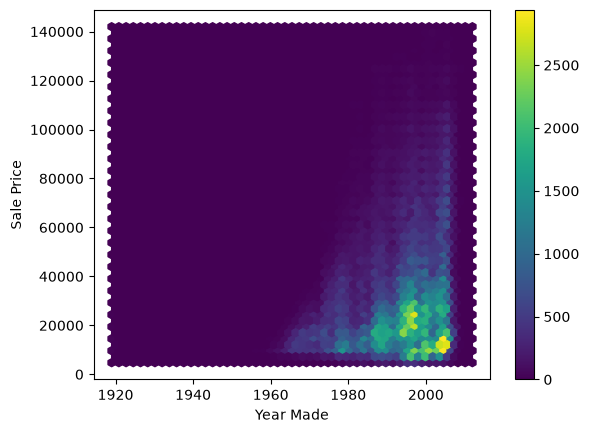

In [23]:
plt.hexbin(yearrestricted["YearMade"], yearrestricted["SalePrice"], gridsize=50)
plt.xlabel("Year Made") 
plt.ylabel("Sale Price") 
plt.colorbar()
plt.show()

In [ ]:
yearrestricted.groupby("YearMade")["SalePrice"].mean()



YearMade
1919    17407.480315
1920    29014.705882
1937    18000.000000
1942    51000.000000
1947     9000.000000
            ...     
2008    49439.946777
2009    49522.594340
2010    53688.793103
2011    64764.516129
2012    35000.000000
Name: SalePrice, Length: 70, dtype: float64

In [38]:

with pd.option_context('display.max_rows', None):
    print(yearrestricted.value_counts("YearMade").sort_index())

YearMade
1919      127
1920       17
1937        1
1942        1
1947        1
1948        3
1949        1
1950        8
1951        7
1952        6
1953        7
1954        3
1955        5
1956       20
1957       16
1958       25
1959       28
1960       97
1961       99
1962      145
1963      250
1964      418
1965      675
1966      951
1967     1104
1968     1260
1969     1544
1970     1321
1971     1720
1972     2141
1973     2547
1974     3113
1975     3240
1976     2718
1977     4425
1978     5693
1979     5613
1980     4744
1981     4190
1982     3048
1983     4603
1984     6174
1985     6547
1986     7588
1987    10191
1988    10546
1989    10785
1990    10379
1991     7461
1992     7711
1993    11181
1994    14471
1995    15806
1996    17001
1997    19269
1998    21751
1999    19274
2000    17238
2001    13385
2002    12473
2003    14661
2004    20914
2005    22096
2006    13426
2007     5048
2008     1691
2009      212
2010       58
2011       31
2012        1
Name: count

Certaines années possèdent trop peu d'observation. On va appliquer un seuil de 50 pour avoir une moyenne qui a du sens

In [45]:
tableau = yearrestricted.groupby("YearMade")["SalePrice"].agg(["mean", "count"]).sort_index()
tableau[tableau["count"] >= 50]

,mean,count
YearMade,,
1919,17407.480315,127
1960,11194.329897,97
1961,11948.989899,99
1962,11756.551724,145
1963,13174.500000,250
1964,12549.162679,418
1965,13163.887407,675
1966,13930.178759,951
1967,14053.170290,1104


1919 première année avant la prochaine. On test si c'est une donnée sentinelle 


In [47]:
yearrestricted[yearrestricted["YearMade"]==1919].isnull().sum()

SalesID                       0
SalePrice                     0
MachineID                     0
ModelID                       0
datasource                    0
auctioneerID                  0
YearMade                      0
MachineHoursCurrentMeter    126
UsageBand                   126
saledate                      0
fiModelDesc                   0
fiBaseModel                   0
fiSecondaryDesc              30
fiModelSeries                87
fiModelDescriptor           122
ProductSize                   8
fiProductClassDesc            0
state                         0
ProductGroup                  0
ProductGroupDesc              0
Drive_System                124
Enclosure                     0
Forks                       102
Pad_Type                    124
Ride_Control                103
Stick                       124
Transmission                 39
Turbocharged                124
Blade_Extension             127
Blade_Width                 127
Enclosure_Type              127
Engine_H

Potentiellement sentinelle car de nombreuses valeurs manquante. Quasi totalité pour heures utilisées mais pas pour les variables obligatoires. 